Importing the libraries

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from transformers import pipeline
from sklearn.linear_model import LinearRegression

**Stage 1: Gathering all the required data for operation**

In [2]:
# ============================================================
# STAGE 1: DATA ACQUISITION
# ============================================================

# Agent 1.1: Scrape live crypto prices from CoinMarketCap
def scrape_crypto_prices():
    print("\n[Agent 1.1] Scraping Crypto Prices...")
    url = "https://coinmarketcap.com/"
    headers = {"User-Agent": "Mozilla/5.0"}
    try:
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status()
    except Exception as e:
        # Fallback if scraping fails
        print("Scraping failed, using fallback data:", e)
        return pd.DataFrame({"Name": ["Bitcoin", "Ethereum"], "Price": [40000, 2500], "Change_24h": [2.5, -1.2]})

    # Parse HTML and extract top 20 cryptos
    soup = BeautifulSoup(response.text, "html.parser")
    rows = soup.select("table.cmc-table tbody tr")
    data = []
    for row in rows[:20]:
        cols = row.select("td")
        if len(cols) > 4:
            name = cols[2].get_text(strip=True)
            price = cols[3].get_text(strip=True).replace("$", "").replace(",", "")
            change_24h = cols[4].get_text(strip=True).replace("%", "")
            data.append({"Name": name, "Price": price, "Change_24h": change_24h})
    return pd.DataFrame(data)

# Agent 1.2: Scrape crypto news headlines from CoinDesk
def scrape_crypto_news():
    print("\n[Agent 1.2] Scraping Crypto News...")
    url = "https://www.coindesk.com/"
    headers = {"User-Agent": "Mozilla/5.0"}
    try:
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status()
    except Exception as e:
        # Fallback headlines if scraping fails
        print("News scraping failed, using fallback headlines:", e)
        return ["Crypto market shows mixed signals", "Bitcoin hits resistance level"]

    soup = BeautifulSoup(response.text, "html.parser")
    headlines = [h.get_text(strip=True) for h in soup.select("h4") if h.get_text(strip=True)]
    return headlines[:5]

# Agent 1.3: Load historical BTC data (simulate for demo)
def load_historical_data():
    print("\n[Agent 1.3] Loading Historical Data...")
    dates = pd.date_range(end=pd.Timestamp.today(), periods=30)
    prices = np.random.uniform(20000, 40000, size=30)
    return pd.DataFrame({"Date": dates, "BTC_Price": prices})

**Stage 2: processing all the datas and analysing it**

In [3]:
# ============================================================
# STAGE 2: DATA PROCESSING & ANALYSIS
# ============================================================

# Agent 2.1: Clean and normalize scraped data
def clean_data(df):
    print("\n[Agent 2.1] Cleaning Data...")
    df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
    df["Change_24h"] = pd.to_numeric(df["Change_24h"], errors="coerce")
    df.dropna(inplace=True)
    return df

# Agent 2.2: Analyze trends (top gainers, losers, volatility)
def analyze_trends(df):
    print("\n[Agent 2.2] Analyzing Trends...")
    top_gainers = df.sort_values(by="Change_24h", ascending=False).head(5)
    top_losers = df.sort_values(by="Change_24h").head(5)
    avg_change = df["Change_24h"].mean()
    volatility = df["Change_24h"].std()
    print(f"Volatility: {volatility:.2f}")
    return top_gainers, top_losers, avg_change, volatility

# Agent 2.3: Perform sentiment analysis on news headlines
def sentiment_analysis(headlines):
    print("\n[Agent 2.3] Sentiment Analysis...")
    sentiment_pipeline = pipeline("sentiment-analysis")
    sentiments = [sentiment_pipeline(h)[0] for h in headlines]
    return sentiments

# Agent 2.4: Calculate risk score (volatility + negative sentiment count)
def risk_scoring(volatility, sentiments):
    print("\n[Agent 2.4] Risk Scoring...")
    sentiment_score = sum([1 if s['label'] == 'NEGATIVE' else 0 for s in sentiments])
    risk_score = volatility + sentiment_score
    print(f"Risk Score: {risk_score:.2f}")
    return risk_score

**Stage 3: prediction and reporting**

In [4]:
# ============================================================
# STAGE 3: PREDICTION & REPORTING
# ============================================================

# Agent 3.1: Predict future prices using Linear Regression
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import numpy as np
from sklearn.linear_model import LinearRegression

def predict_prices(df):
    print("\n[Agent 3.1] Predicting Prices...")

    X = np.arange(len(df)).reshape(-1, 1)
    y = df["Price"].values

    model = LinearRegression()
    model.fit(X, y)

    future_X = np.array([[len(df) + i] for i in range(1, 6)])
    predictions = model.predict(future_X)

    return predictions



# Agent 3.2: Generate summary report using Hugging Face summarizer


def generate_report(df, top_gainers, top_losers, avg_change, predictions, hist_df, risk_score):
    import matplotlib.pyplot as plt
    import numpy as np
    from transformers import pipeline

    print("\n[Agent 3.2] Generating Report...")

    summarizer = pipeline("summarization", model="facebook/bart-large-cnn")
    recommendation = "High Risk! Avoid trading." if risk_score > 5 else "Market looks stable."
    summary_text = f"""
    Crypto Market Summary:
    Avg Change: {avg_change:.2f}%
    Risk Score: {risk_score:.2f} ({recommendation})
    Top Gainers: {', '.join(top_gainers['Name'].tolist())}
    Top Losers: {', '.join(top_losers['Name'].tolist())}
    Predictions: {predictions.tolist()}
    """
    summary = summarizer(summary_text, max_length=120, min_length=50, do_sample=False)[0]['summary_text']
    print("\n=== MARKET SUMMARY ===")
    print(summary)

    print("\n[Agent 3.3] Creating Gainers/Losers Image...")
    top_n = 5
    g_names = top_gainers["Name"].head(top_n).tolist()
    l_names = top_losers["Name"].head(top_n).tolist()
    max_len = 22
    shorten = lambda s: s if len(s) <= max_len else s[:max_len-1] + "…"
    g_names = [shorten(x) for x in g_names]
    l_names = [shorten(x) for x in l_names]
    fig, ax = plt.subplots(figsize=(8,4))
    ax.axis("off")
    table_data = [["TOP GAINERS", "TOP LOSERS"]] + [list(x) for x in zip(g_names, l_names)]
    tbl = ax.table(cellText=table_data, cellLoc="left", colWidths=[0.48, 0.48], loc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(12)
    tbl.scale(1, 1.2)
    for (r, c), cell in tbl.get_celld().items():
        if r == 0:
            cell.set_text_props(weight="bold")
            cell.set_facecolor("#f2f2f2")
            cell.set_height(cell.get_height() * 1.1)
    ax.set_title("Top Gainers & Losers (24h)", fontsize=16, pad=10)
    plt.tight_layout()
    plt.savefig("gainers_losers.png", bbox_inches="tight", dpi=150)
    plt.show()
    print("Saved image: gainers_losers.png")

    print("\n[Agent 3.4] Creating Price Comparison Chart...")
    prev_price = df["Price"] / (1 + df["Change_24h"]/100)
    price_diff = df["Price"] - prev_price
    plot_df = df.copy()
    plot_df["Price_Diff"] = price_diff
    def shorten(name, max_len=18):
        return name if len(name) <= max_len else name[:max_len-1] + "…"
    plot_df["Label"] = plot_df["Name"].apply(shorten)
    plot_df = plot_df.sort_values(by="Price_Diff", key=lambda s: np.abs(s), ascending=False)
    TOP_N = 15
    if TOP_N is not None and len(plot_df) > TOP_N:
        plot_df = plot_df.head(TOP_N)
    colors = np.where(plot_df["Price_Diff"] >= 0, "#2ca02c", "#d62728")
    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.barh(plot_df["Label"], plot_df["Price_Diff"], color=colors, edgecolor="none")
    ax.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.6)
    max_abs = plot_df["Price_Diff"].abs().max() or 1
    for y, val in enumerate(plot_df["Price_Diff"]):
        ax.text(val + (0.01 * max_abs) * (1 if val >= 0 else -1), y, f"{val:,.2f}", va="center", ha="left" if val >= 0 else "right", fontsize=9, color="black")
    ax.set_title("Price Change (Δ) from Previous Price — Largest Movers", fontsize=16, pad=12)
    ax.set_xlabel("Price Change")
    ax.grid(True, axis="x", linestyle=":", alpha=0.4)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=10)
    plt.tight_layout()
    plt.savefig("price_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved image: price_comparison.png")

    print("\n[Agent 3.5] Creating Main Dashboard...")
    fig, axes = plt.subplots(2, 3, figsize=(18,10))
    axes[0,0].bar(df["Name"], df["Change_24h"], color=["green" if x>0 else "red" for x in df["Change_24h"]])
    axes[0,0].set_title("24h Price Change (%)")
    axes[0,0].tick_params(axis='x', rotation=90)
    axes[0,1].plot(hist_df["Date"], hist_df["BTC_Price"], marker="o")
    axes[0,1].set_title("BTC Historical Price Trend")
    axes[0,2].plot(range(1,len(predictions)+1), predictions, marker="o")
    axes[0,2].set_title("Future Price Predictions")
    axes[0,2].set_xlabel("Days Ahead")
    axes[0,2].set_ylabel("Predicted Price")
    axes[1,0].bar(top_gainers["Name"], top_gainers["Change_24h"], color="green")
    axes[1,0].set_title("Top Gainers")
    axes[1,0].tick_params(axis='x', rotation=45)
    axes[1,1].bar(top_losers["Name"], top_losers["Change_24h"], color="red")
    axes[1,1].set_title("Top Losers")
    axes[1,1].tick_params(axis='x', rotation=45)
    axes[1,2].barh(["Risk Score"], [risk_score])
    axes[1,2].set_xlim(0,10)
    axes[1,2].set_title("Market Risk Indicator")
    plt.tight_layout()
    plt.savefig("crypto_dashboard.png")
    plt.show()
    print("Dashboard saved as crypto_dashboard.png")







**MAIN WORKFLOW PIPELINE**

In [5]:
# Stage 1: Acquire data
crypto_df = scrape_crypto_prices()
crypto_df = clean_data(crypto_df)
hist_df = load_historical_data()
headlines = scrape_crypto_news()



[Agent 1.1] Scraping Crypto Prices...

[Agent 2.1] Cleaning Data...

[Agent 1.3] Loading Historical Data...

[Agent 1.2] Scraping Crypto News...


In [6]:
# Display datasets with labels and comments
print("\n=== Live Crypto Prices (Cleaned) ===")
print("Comment: Current market snapshot after cleaning.")
display(crypto_df.head())

print("\n=== Historical Crypto OHLCV ===")
print("Comment: Past price data for analysis.")
display(hist_df.head())

print("\n=== Latest Crypto News Headlines ===")
print("Comment: Recent news items related to crypto.")
display(headlines.head() if hasattr(headlines, 'head') else headlines)


=== Live Crypto Prices (Cleaned) ===
Comment: Current market snapshot after cleaning.


,Name,Price,Change_24h
0,CoinMarketCap 20 Index DTFCMC20,193.9400,0.33
1,BitcoinBTC,91048.6700,0.25
2,EthereumETH,3144.3700,0.36
3,TetherUSDT,0.9989,0.03
4,XRPXRP,2.1800,0.70



=== Historical Crypto OHLCV ===
Comment: Past price data for analysis.


,Date,BTC_Price
0,2025-12-09 19:44:14.399746,37008.959612
1,2025-12-10 19:44:14.399746,36158.624546
2,2025-12-11 19:44:14.399746,37463.881765
3,2025-12-12 19:44:14.399746,34218.753488
4,2025-12-13 19:44:14.399746,37714.643206



=== Latest Crypto News Headlines ===
Comment: Recent news items related to crypto.


[]

In [7]:
# Stage 2: Analyze data
gainers, losers, avg_change, volatility = analyze_trends(crypto_df)
sentiments = sentiment_analysis(headlines)
risk_score = risk_scoring(volatility, sentiments)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.



[Agent 2.2] Analyzing Trends...
Volatility: 0.21

[Agent 2.3] Sentiment Analysis...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cpu



[Agent 2.4] Risk Scoring...
Risk Score: 0.21


In [8]:
# Decision Node: Risk-based recommendation
if risk_score > 5:
    print("\n[Decision Node] High Risk detected! Adding warning to report...")


[Agent 3.1] Predicting Prices...

[Agent 3.2] Generating Report...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cpu



=== MARKET SUMMARY ===
Crypto Market Summary: XRPXRP, TRONTRX, CardanoADA, ChainlinkLINK, DogecoinDOGE. Top Losers: USDCUSDC, TetherUSDT, UNUS SED LEOLEO, HyperliquidHYPE, BitcoinBTC. Predictions: [-11674.265307380945, -13683.238445238087, -15692.211583095232, -17701.18472095237]

[Agent 3.3] Creating Gainers/Losers Image...


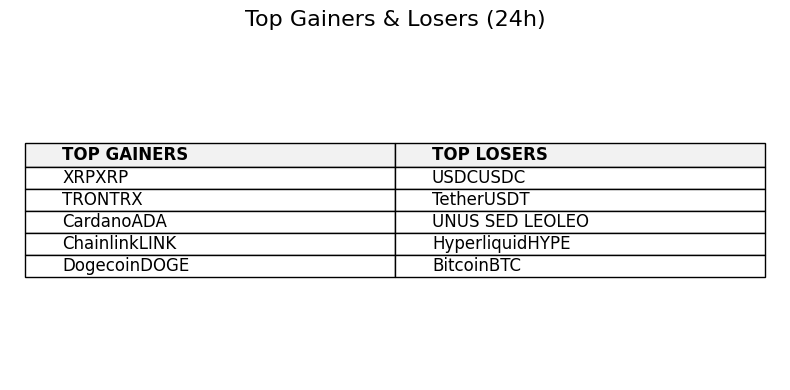

Saved image: gainers_losers.png

[Agent 3.4] Creating Price Comparison Chart...


/tmp/ipython-input-421603770.py:102: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=10)


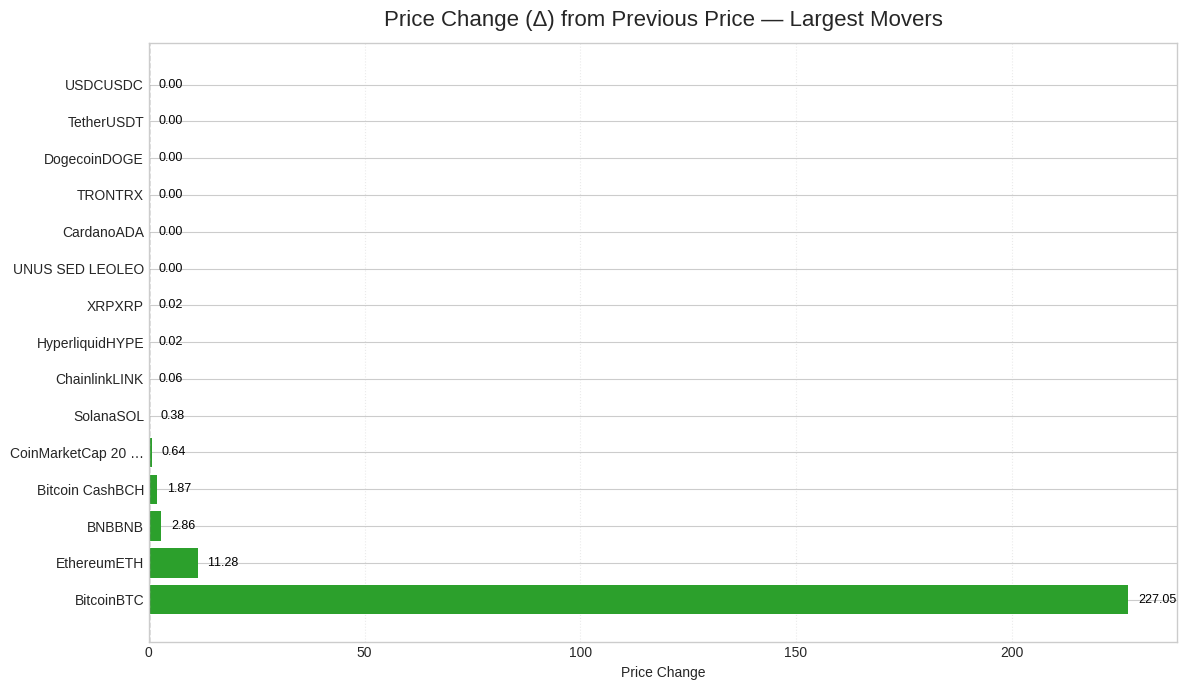

Saved image: price_comparison.png

[Agent 3.5] Creating Main Dashboard...


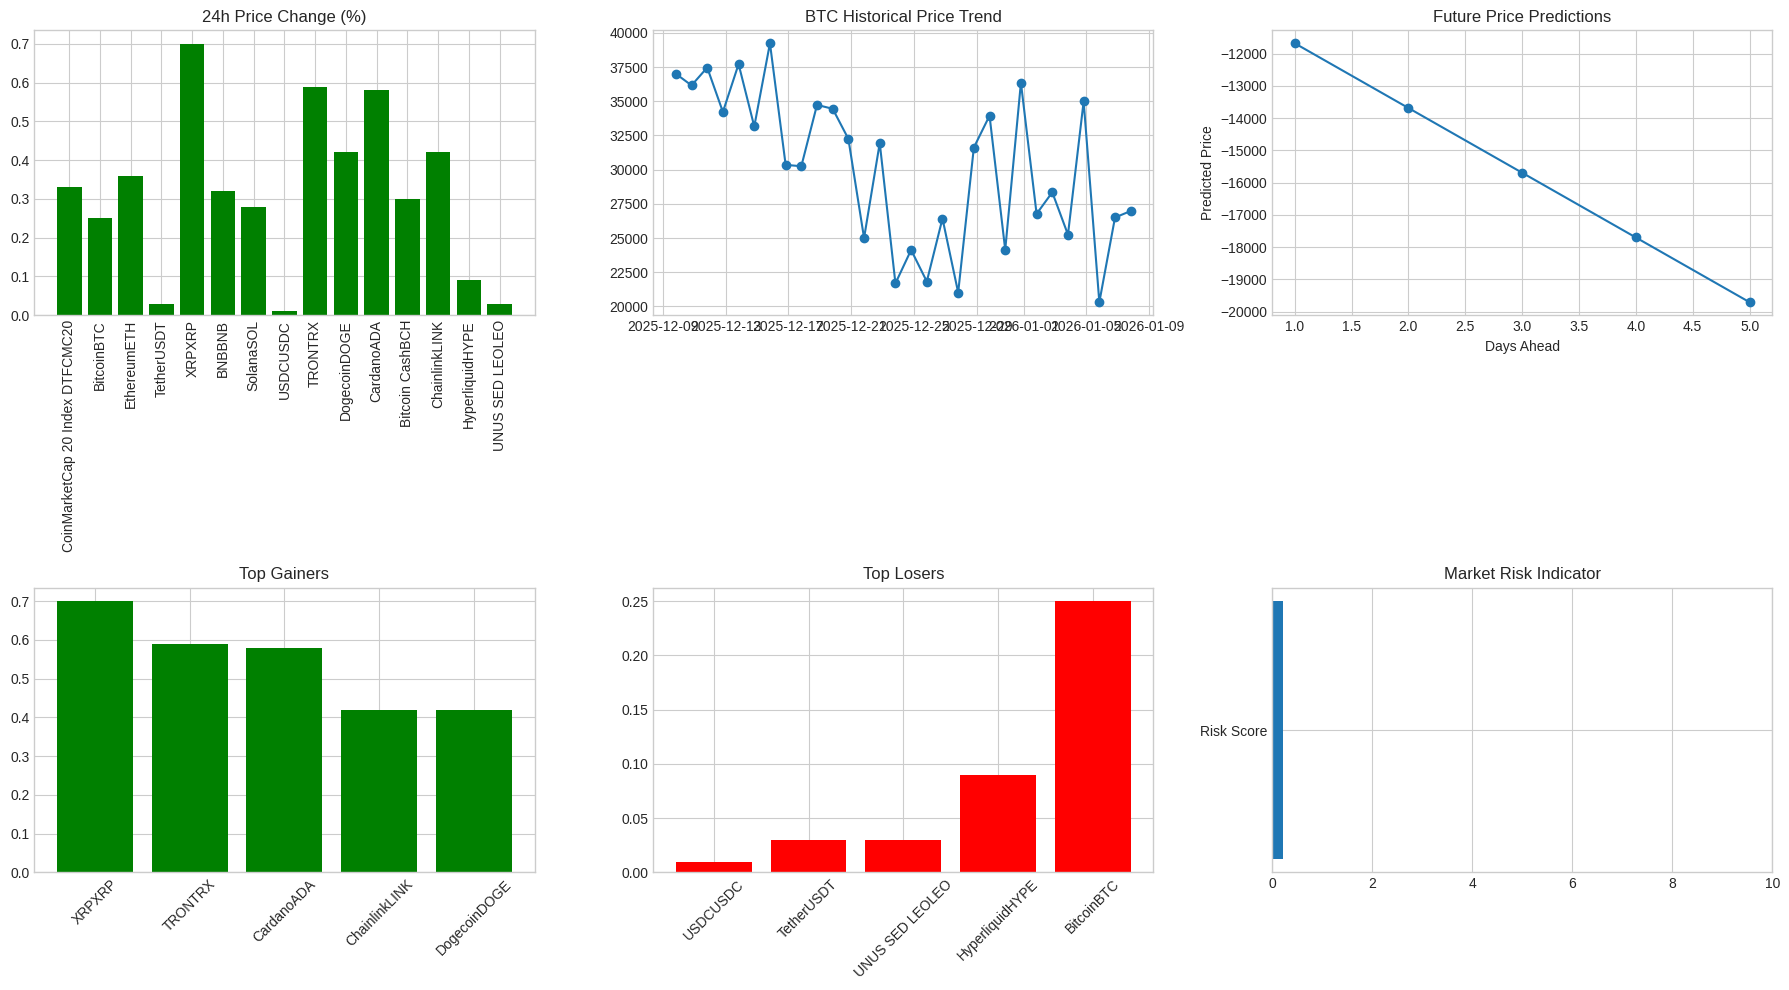

Dashboard saved as crypto_dashboard.png


In [9]:
# Stage 3: Predict and report
predictions = predict_prices(crypto_df)
generate_report(crypto_df, gainers, losers, avg_change, predictions, hist_df, risk_score)